In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
root_dir = os.path.abspath('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    fbeta_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder

train = pd.read_csv(os.path.join(root_dir, 'data/titanic/train.csv'))
train=train.drop("PassengerId",axis=1)
test = pd.read_csv(os.path.join(root_dir, 'data/titanic/test.csv'))
y=train['Survived']


/home/andrew/ml/my_project/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/andrew/ml/my_project/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 61.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


Pclass  Sex     Survived
1       female  1           0.968085
                0           0.031915
        male    0           0.631148
                1           0.368852
2       female  1           0.921053
                0           0.078947
        male    0           0.842593
                1           0.157407
3       female  1           0.500000
                0           0.500000
        male    0           0.864553
                1           0.135447
Name: proportion, dtype: float64

/home/andrew/ml/my_project/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 7.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/andrew/ml/my_project/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 38.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/andrew/ml/my_project/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 66.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


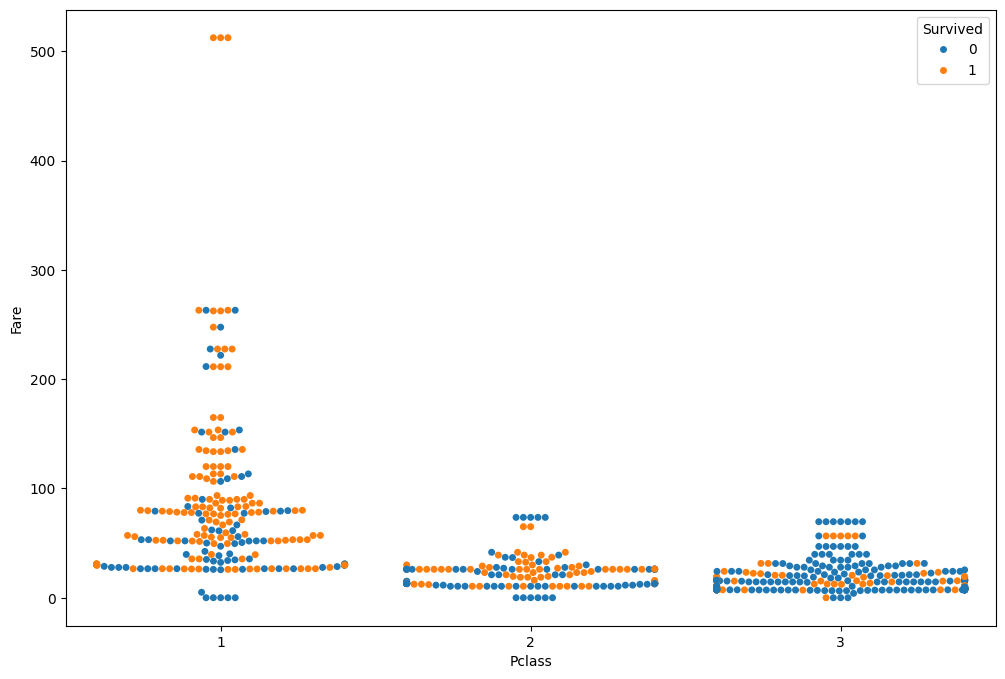

In [2]:
#влияние цены билета и класса
fig = plt.figure(figsize=(12,8))
sns.swarmplot(x="Pclass", y="Fare", data=train, hue="Survived")

#влияние класса и пола
train.groupby(['Pclass','Sex'])['Survived'].value_counts(normalize=True)



Женщины имели колоссальное преимущество в выживаемости по сравнению с мужчинами. Среди женщин 1-го класса выжило 96%, 2-го класса — 92%. Даже в самом бедном 3-ем классе выжила половина женщин 50%.

Также прослеживается зависимость выживаемости от класса

In [3]:
train.select_dtypes(include=['number']).groupby("Survived").mean()




,Pclass,Age,SibSp,Parch,Fare
Survived,,,,,
0,2.531876,30.626179,0.553734,0.329690,22.117887
1,1.950292,28.343690,0.473684,0.464912,48.395408


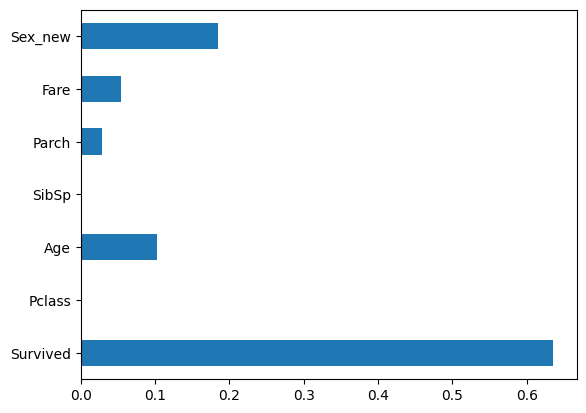

In [4]:
train_copy = train.copy()
train_copy['Sex_new'] = train_copy['Sex'].map({'male': 0, 'female': 1})

train_clean = train_copy.dropna()
train_clean = train_clean.select_dtypes(include=['number'])
y_clean = y[train_clean.index] 

importances = mutual_info_classif(train_clean, y_clean)
feature_importances = pd.Series(importances, index=train_clean.columns)
feature_importances.plot(kind='barh')
plt.show()

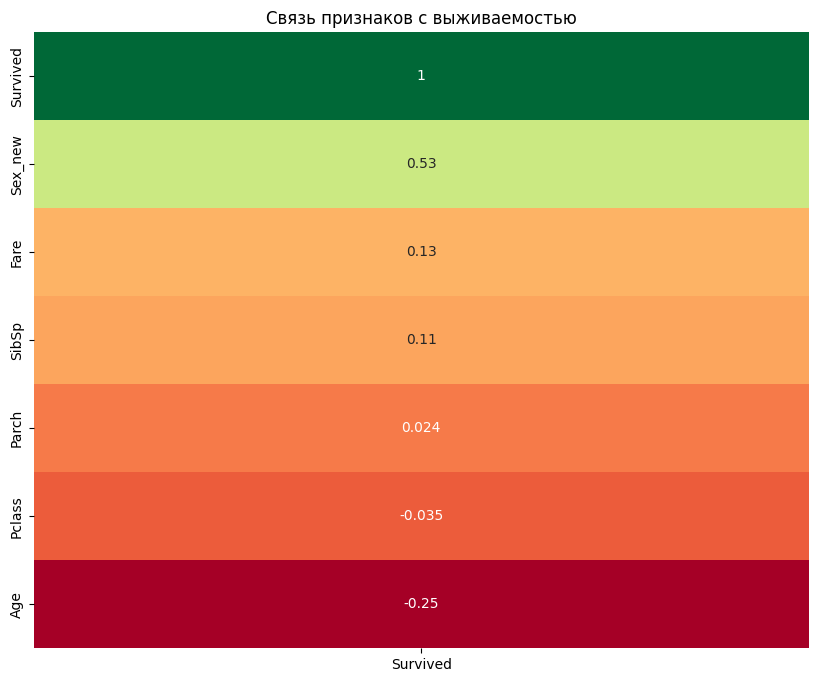

In [5]:

target_corr = train_clean.select_dtypes(include=['number']).corr()['Survived'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.heatmap(target_corr.to_frame(), annot=True, cmap='RdYlGn', cbar=False)
plt.title('Связь признаков с выживаемостью')
plt.show()

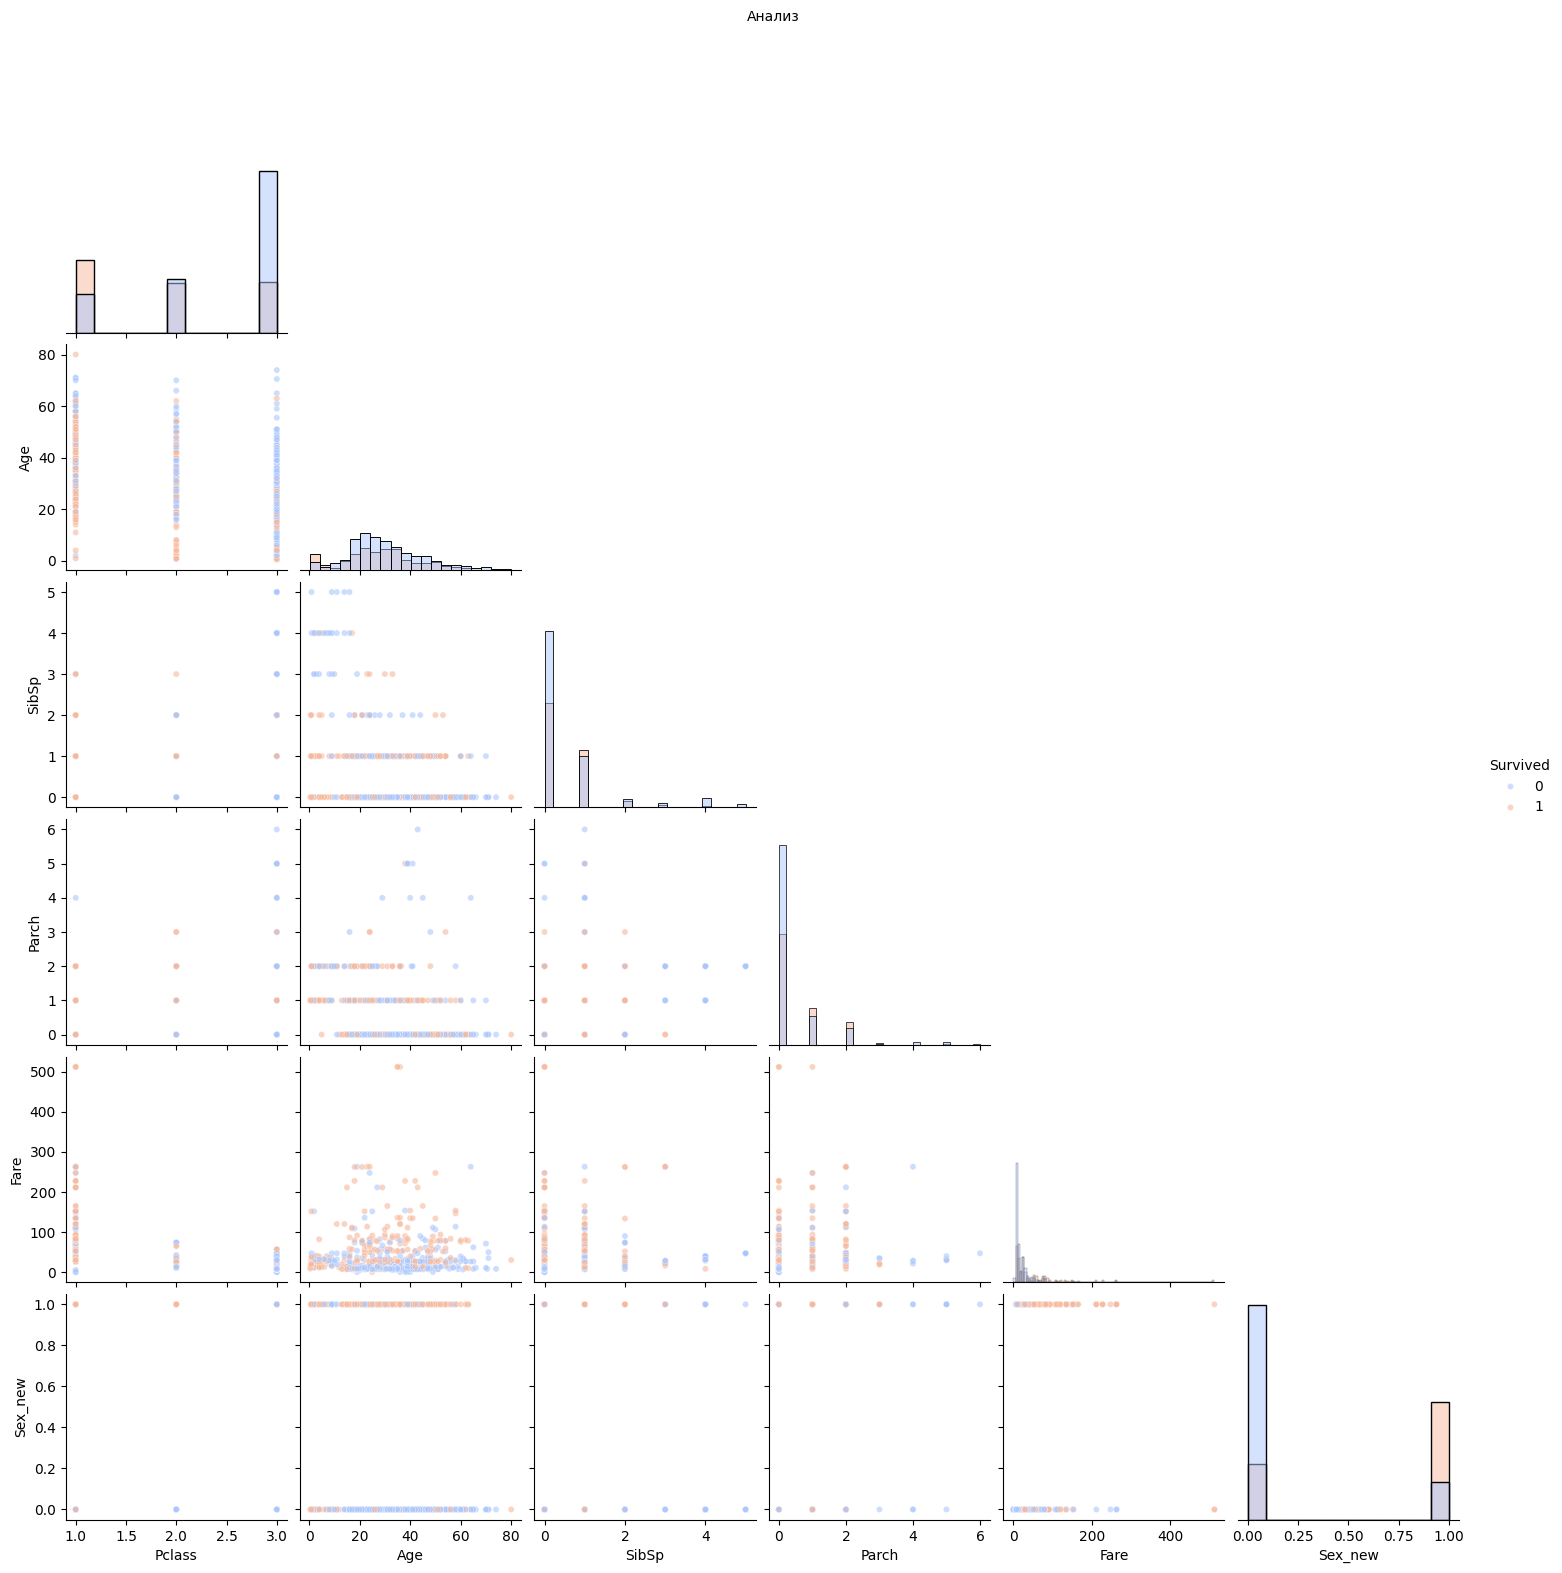

In [6]:
numeric_cols = train_copy.select_dtypes(include='number').columns.tolist()
plot_data = train_copy[numeric_cols].dropna()
sns.pairplot(plot_data, 
             hue='Survived',  # раскраска по целевой переменной
             palette='coolwarm',
             plot_kws={'alpha': 0.6, 's': 20},
             diag_kind='hist', 
             corner=True)    

plt.suptitle('Анализ',y=1.05, fontsize=10)
plt.show()


# Хорошие индикаторы
- У кого лучше класс, у тех больше была вероятность на выживание
- Дети с возрастом < 10 чаще выживали
- у кого дороже билет, те чаще выживали
- Небольшие семьи чаще выживали
- Женжины(в зависимости от класса) лучше выживали

SibSp — количество братьев/сестёр/супругов (у большинства 0-1)
Parch — количество родителей/детей (у большинства 0)

Можно объединить SibSp и Parch

Cabin удалю, Age средним, 
Embarked самым часто встречающимся значением



In [7]:
#processing
train_copy = train.copy()
train_copy['family'] = train_copy['SibSp']+train_copy['Parch']
train_copy['isAlone'] = (train_copy['family']==0).astype(int)
train_copy['Sex_new'] = train_copy['Sex'].map({'male': 0, 'female': 1})
train_copy = train_copy.drop(['SibSp', 'Parch', 'Cabin','Sex'], axis=1)
train_copy['Age']=train_copy['Age'].fillna(train_copy['Age'].mean(), inplace=True)
train_copy['Embarked']=train_copy['Embarked'].fillna('S',inplace=True)

train_copy['Title'] = train_copy['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
print(train_copy['Title'].value_counts())

main_titles = ['Mr', 'Miss', 'Mrs', 'Master']
train_copy.loc[~train_copy['Title'].isin(main_titles), 'Title'] = 'Rare'

train_copy = train_copy.drop(['Ticket','Name'],axis=1)

"""train_copy = pd.get_dummies(train_copy, columns=['Embarked'], prefix='Embarked', drop_first=True)
train_copy = pd.get_dummies(train_copy, columns=['Title'],   prefix='Title',   drop_first=True )"""

train_copy['Fare'] = np.log1p(train_copy['Fare'])

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded_array = ohe.fit_transform(train_copy[['Embarked', 'Title']])

encoded_df = pd.DataFrame(
    encoded_array,
    columns=ohe.get_feature_names_out(['Embarked', 'Title']),
    index=train_copy.index
)

train_copy = pd.concat([train_copy.drop(['Embarked', 'Title'], axis=1), encoded_df], axis=1)



Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


/tmp/ipykernel_725/513349479.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_copy['Age']=train_copy['Age'].fillna(train_copy['Age'].mean(), inplace=True)
/tmp/ipykernel_725/513349479.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such

In [8]:
#Pipline
X = train_copy.drop('Survived', axis=1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(random_state=42, max_iter=1000, solver='lbfgs')
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, pos_label=1):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred, pos_label=1):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred, pos_label=1):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")

Accuracy : 0.8436
Precision: 0.8154
Recall   : 0.7681
F1-Score : 0.7910
ROC-AUC  : 0.8743


In [9]:
solvers = ['lbfgs', 'liblinear', 'saga']
results = {}

for svr in solvers:
    model_svr = LogisticRegression(random_state=42, max_iter=5000, solver=svr)
    model_svr.fit(X_train_scaled, y_train)
    
    y_pred_svr = model_svr.predict(X_test_scaled)
    y_prob_svr = model_svr.predict_proba(X_test_scaled)[:, 1]
    
    results[svr] = {
        'Accuracy': accuracy_score(y_test, y_pred_svr),
        'Precision': precision_score(y_test, y_pred_svr, pos_label=1),
        'Recall': recall_score(y_test, y_pred_svr, pos_label=1),
        'F1-Score': f1_score(y_test, y_pred_svr, pos_label=1),
        'ROC-AUC': roc_auc_score(y_test, y_prob_svr)
    }

df_compare = pd.DataFrame(results).T
print("Сравнение моделей по типам solver:")
display(df_compare.round(4))

Сравнение моделей по типам solver:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
lbfgs,0.8436,0.8154,0.7681,0.791,0.8743
liblinear,0.8436,0.8154,0.7681,0.791,0.8743
saga,0.8436,0.8154,0.7681,0.791,0.8743
